In [1]:
# ## Imports

import pickle
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, recall_score
from xgboost import XGBClassifier

MODEL_BASE_PATH  = Path("../baseline_models/cardio_xgb_baseline_model.pkl")
MODEL_REFINED_PATH  = Path("../refined_models")
DATA_DIR = Path("../../data/test_train_val_sets")
OUTPUT_DIR = Path("../../outputs/models")

In [2]:
# ## 1 · Load Splits

train_df = pd.read_csv(DATA_DIR/ "cardio_baseline_train.csv")
val_df   = pd.read_csv(DATA_DIR/ "cardio_baseline_val.csv")
test_df  = pd.read_csv(DATA_DIR/ "cardio_baseline_test.csv")

print(train_df.columns)
X_train = train_df.drop(columns=["cardio", "stratify"])
y_train = train_df["cardio"]

X_val = val_df.drop(columns=["cardio", "stratify"])
y_val = val_df["cardio"]

X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]

female_mask_test = test_df["gender"].values == 0
male_mask_test   = test_df["gender"].values == 1

with open(MODEL_BASE_PATH, "rb") as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'stratify'],
      dtype='str')


In [3]:
import json

with open("../../config/dataset_split_sizes.json", "r") as f:
    expected = json.load(f)

assert len(train_df) == expected["train"], "Train size mismatch"
assert len(val_df)   == expected["val"],   "Val size mismatch"
assert len(test_df)  == expected["test"],  "Test size mismatch"

print("Dataset sizes validated.")


Dataset sizes validated.


In [4]:
# ## 2 · Feature Engineering

X_train_fe = X_train.copy()
X_val_fe   = X_val.copy()
X_test_fe  = X_test.copy()

for df in [X_train_fe, X_val_fe, X_test_fe]:
    df["pulse_pressure"]       = df["ap_hi"] - df["ap_lo"]
    df["chol_gluc_interact"]   = df["cholesterol"] * df["gluc"]
    df["metabolic_risk_score"] = (df["cholesterol"] - 1) + (df["gluc"] - 1)  # range: 0–4
    df["BSA"] = np.sqrt((df["height"] * df["weight"]) / 3600).round(2)
    df.drop(columns=["ap_lo", "height"], inplace=True)

print("Feature set:", X_train_fe.columns.tolist())

# Save FE splits with labels
for split, X, y in [
    ("train", X_train_fe, y_train),
    ("val",   X_val_fe,   y_val),
    ("test",  X_test_fe,  y_test),
]:
    out = X.copy()
    out["cardio"] = y.values
    print(len(X_test_fe))
    out.to_csv(DATA_DIR/ "cardio_fe_{split}.csv", index=False)

print("Saved FE splits.")

Feature set: ['gender', 'weight', 'ap_hi', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'pulse_pressure', 'chol_gluc_interact', 'metabolic_risk_score', 'BSA']
10227
10227
10227
Saved FE splits.


In [5]:
# ## 3 · Hyperparameter Tuning (RandomizedSearchCV)

param_dist = {
    "n_estimators":    [100, 200, 300, 500],
    "max_depth":       [3, 4, 5, 6],
    "learning_rate":   [0.01, 0.03, 0.05, 0.1],
    "min_child_weight":[1, 3, 5],
    "subsample":       [0.7, 0.8, 1.0],
    "colsample_bytree":[0.7, 0.8, 1.0],
    "gamma":           [0, 0.1, 0.3],
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="logloss"),
    param_distributions=param_dist,
    n_iter=30,
    scoring="recall",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train_fe, y_train)
print("Best params:", search.best_params_)
print("Best CV recall:", search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV recall: 0.6966377669697611


In [6]:
# ## 4 · Model Variants

# ── 4a. Tuned model ───────────────────────────────────────
model_tuned = XGBClassifier(
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=1.0,
    learning_rate=0.05,
    n_estimators=200,
    gamma = 0,
    random_state=42,
)
model_tuned.fit(X_train, y_train)

# ── 4b. Monotone ap_hi (clipped at 100) ──────────────────
X_train_mod = X_train.copy()
X_val_mod   = X_val.copy()
X_test_mod  = X_test.copy()

for df in [X_train_mod, X_val_mod, X_test_mod]:
    df["ap_hi"] = df["ap_hi"].clip(lower=100)

feature_list = X_train_mod.columns.tolist()
monotone     = [0] * len(feature_list)
monotone[feature_list.index("ap_hi")] = 1

model_monotone = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
    monotone_constraints=tuple(monotone),
)
model_monotone.fit(X_train_mod, y_train, eval_set=[(X_val_mod, y_val)], verbose=False)

# ── 4c. Sample-weighted (high-risk CVD cases) ─────────────
sample_weights = np.ones(len(X_train))
high_risk_mask = (
    (train_df["cholesterol"].values == 3) &
    (train_df["gluc"].values == 3) &
    (y_train.values == 1)
)
print(f"High-risk CVD cases upweighted: {high_risk_mask.sum()}")
sample_weights[high_risk_mask] = 50

model_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
)
model_weighted.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

# ── 4d. Interaction-constrained model ────────────────────
interaction_constraints = [
    ["ap_hi", "ap_lo"],
    ["age_years", "gender", "weight", "height"],
    ["cholesterol", "gluc"],
    ["smoke", "alco", "active"],
]

model_constrained = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
    interaction_constraints=interaction_constraints,
)
model_constrained.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# ── 4e. Pulse pressure model (ap_hi dropped) ─────────────
# X_train_pp = X_train.copy()
# X_val_pp   = X_val.copy()
# X_test_pp  = X_test.copy()

# for df in [X_train_pp, X_val_pp, X_test_pp]:
#     df["pulse_pressure"]     = df["ap_hi"] - df["ap_lo"]
#     df["chol_gluc_interact"] = df["cholesterol"] * df["gluc"]
#     df.drop(columns=["ap_hi"], inplace=True)

# Drop ap_lo, keep ap_hi, add all engineered features, scale_pos_weight
# for df in [X_train_fe, X_val_fe, X_test_fe]:
#     df["pulse_pressure"]       = df["ap_hi"] - df["ap_lo"]
#     df["BSA"]                  = np.sqrt((df["height"] * df["weight"]) / 3600).round(2)
#     df["chol_gluc_interact"]   = df["cholesterol"] * df["gluc"]
#     df["metabolic_risk_score"] = (df["cholesterol"] - 1) + (df["gluc"] - 1)
#     df["high_metabolic_risk"]  = ((df["cholesterol"] == 3) & (df["gluc"] == 3)).astype(int)
    # df.drop(columns=["ap_lo", "height"], inplace=True)

# model_pp = XGBClassifier(
#     n_estimators=500, max_depth=4, learning_rate=0.05,
#     random_state=42, early_stopping_rounds=10,
#     interaction_constraints=[
#         ["cholesterol", "gluc", "chol_gluc_interact"],
#         ["gender", "height", "smoke", "alco"],
#         ["age_years", "weight"],
#         ["active"],
#     ],
# )
# model_pp.fit(X_train_pp, y_train, eval_set=[(X_val_pp, y_val)], verbose=False)

# ── 4f. Feature-engineered model ──────────────────────────
model_fe = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
    scale_pos_weight=1.5,
)
model_fe.fit(X_train_fe, y_train, eval_set=[(X_val_fe, y_val)], verbose=False)

High-risk CVD cases upweighted: 1664


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [7]:
# ## 5 · Export All Models

models_to_save = {
    MODEL_REFINED_PATH/ "cardio_xgb_tuned.pkl":       model_tuned,
    MODEL_REFINED_PATH/ "cardio_xgb_monotone.pkl":    model_monotone,
    MODEL_REFINED_PATH/ "cardio_xgb_weighted.pkl":    model_weighted,
    MODEL_REFINED_PATH/ "cardio_xgb_constrained.pkl": model_constrained,
    # MODEL_REFINED_PATH/ "cardio_xgb_pp.pkl":          model_pp,
    MODEL_REFINED_PATH/ "cardio_xgb_fe.pkl":          model_fe,
}

for path, m in models_to_save.items():
    with open(path, "wb") as f:
        pickle.dump(m, f)
    print(f"Saved: {path}")

Saved: ..\refined_models\cardio_xgb_tuned.pkl
Saved: ..\refined_models\cardio_xgb_monotone.pkl
Saved: ..\refined_models\cardio_xgb_weighted.pkl
Saved: ..\refined_models\cardio_xgb_constrained.pkl
Saved: ..\refined_models\cardio_xgb_fe.pkl


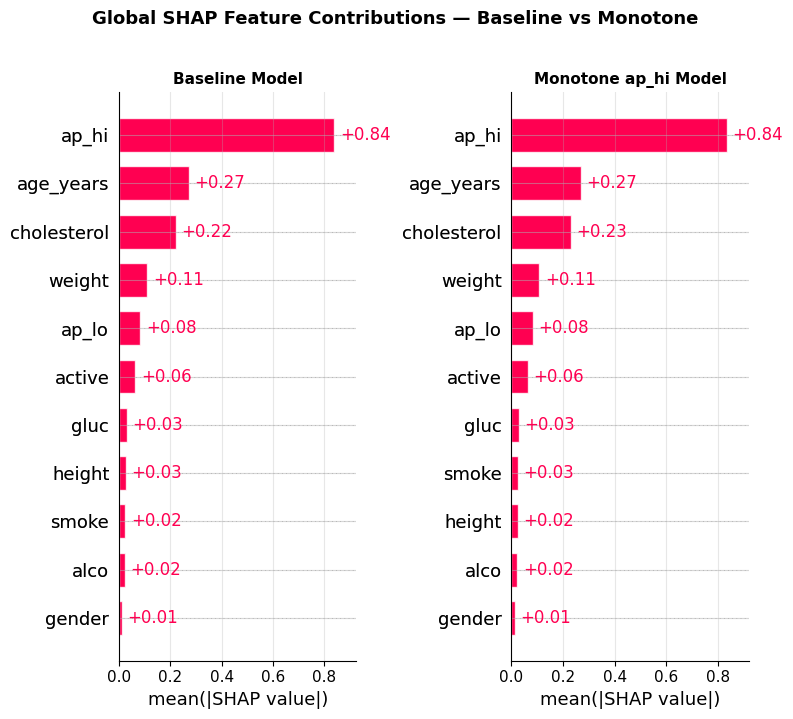

In [8]:
# ## 6 · SHAP Global Comparison

explainer_base = shap.TreeExplainer(model)
explainer_mono = shap.TreeExplainer(model_monotone)
# explainer_fe = shap.TreeExplainer(model_fe)

# explainer_pp   = shap.TreeExplainer(model_pp)

sv_base = explainer_base(X_test)
sv_mono = explainer_mono(X_test_mod)
# sv_fe = explainer_fe(X_test_fe)

# sv_pp   = explainer_pp(X_test_pp)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sv, ax, title in [
    (sv_base, axes[0], "Baseline Model"),
    (sv_mono, axes[1], "Monotone ap_hi Model"),
]:
    plt.sca(ax)
    shap.plots.bar(sv, max_display=12, show=False)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)

fig.suptitle("Global SHAP Feature Contributions — Baseline vs Monotone",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_global_baseline_vs_monotone.png", 
            dpi=150, bbox_inches="tight")
plt.show()


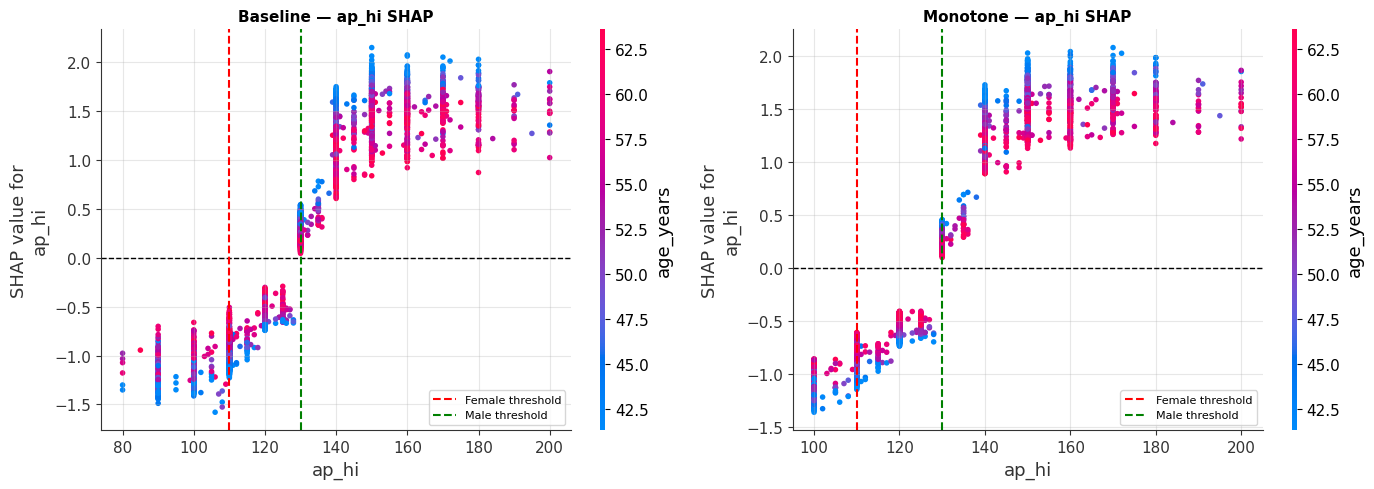

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sv, X, ax, title in [
    (sv_base, X_test,     axes[0], "Baseline — ap_hi SHAP"),
    (sv_mono, X_test_mod, axes[1], "Monotone — ap_hi SHAP"),
]:
    shap.dependence_plot("ap_hi", sv.values, X, 
                         ax=ax, show=False)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
    ax.axvline(x=110, color="red", linestyle="--", linewidth=1.5, label="Female threshold")
    ax.axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male threshold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_dependence_baseline_vs_monotone.png",
            dpi=150, bbox_inches="tight")
plt.show()